<a href="https://colab.research.google.com/github/bungalunnac/uas_pm_bencana/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌏 Global Natural Disaster Frequency Analysis & Prediction
## EM-DAT Emergency Events Database (1900–2023)

**Author:** Bungalunna Nashuha Camelia — Computer Science, Dian Nuswantoro University  
**Course:** Machine Learning — UAS Genap 2025/2026  
**Dataset:** [EM-DAT on Kaggle](https://www.kaggle.com/datasets/mexwell/natural-disasters-emergency-events-database)

---

### Problem Statement
Natural disasters are frequently cited as increasing in frequency worldwide, yet many such claims rely on news coverage rather than systematic quantitative analysis. This project asks: **can 124 years of historical disaster records quantify the long-term trend in disaster frequency per country and disaster type, and predict how many events will occur in 2027?**

### Business Objective
To provide data-driven evidence of disaster frequency trends to support disaster management agencies (e.g. BNPB, UNDRR) in planning mitigation strategies and resource allocation.

### Success Criteria
- Mean Absolute Error (MAE) < 0.5 events per prediction period for the best model
- The best model outperforms a naive baseline (predicting the historical mean)
- Trend analysis confirms or refutes the hypothesis that disaster frequency is increasing

### Methodology: CRISP-DM
1. **Business Understanding** — Define the problem and success criteria  
2. **Data Understanding** — Explore and characterize the EM-DAT dataset  
3. **Data Preparation** — Aggregate, filter, normalize, and split the data  
4. **Modeling** — Train Linear Regression and KNN Regression *(Notebook 2)*  
5. **Evaluation** — Compare models using MAE, RMSE, R², and residual analysis *(Notebook 3)*  
6. **Deployment** — Save predictions and summarize findings

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load EM-DAT dataset
df = pd.read_csv('/content/_EmergencyEventsDatabase-CountryProfiles_emdat-country-profiles_2023_04_06.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (10431, 13)

Columns: ['Year', 'Country', 'ISO', 'Disaster Group', 'Disaster Subroup', 'Disaster Type', 'Disaster Subtype', 'Total Events', 'Total Affected', 'Total Deaths', 'Total Damage (USD, original)', 'Total Damage (USD, adjusted)', 'CPI']


,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,1900,Cabo Verde,CPV,Natural,Climatological,Drought,Drought,1,NaN,11000.0,NaN,NaN,"2,8490844088613"
1,1900,India,IND,Natural,Climatological,Drought,Drought,1,NaN,1250000.0,NaN,NaN,"2,8490844088613"
2,1900,Jamaica,JAM,Natural,Hydrological,Flood,NaN,1,NaN,300.0,NaN,NaN,"2,8490844088613"
3,1900,Japan,JPN,Natural,Geophysical,Volcanic activity,Ash fall,1,NaN,30.0,NaN,NaN,"2,8490844088613"
4,1900,Turkey,TUR,Natural,Geophysical,Earthquake,Ground movement,1,NaN,140.0,NaN,NaN,"2,8490844088613"


## 📊 Step 1: Data Loading & Initial Exploration
We load the EM-DAT dataset and perform an initial inspection to understand its structure, size, data types, and data quality issues before any analysis begins.

In [3]:
# Initial exploration dataset
print("=== Disaster Type ===")
print(df['Disaster Type'].value_counts())

print("\n=== Disaster Subroup ===")
print(df['Disaster Subroup'].value_counts())

print("\n=== Available Years ===")
print(f"From {df['Year'].min()} to {df['Year'].max()}")

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Top 10 Countries ===")
print(df['Country'].value_counts().head(10))

print("\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n=== Descriptive Statistics ===")
df.describe()

=== Disaster Type ===
Disaster Type
Flood                    3837
Storm                    2761
Earthquake               1087
Drought                   784
Landslide                 652
Extreme temperature       565
Wildfire                  374
Volcanic activity         231
Insect infestation         92
Mass movement (dry)        44
Glacial lake outburst       2
Fog                         1
Animal accident             1
Name: count, dtype: int64

=== Disaster Subroup ===
Disaster Subroup
Hydrological      4489
Meteorological    3327
Geophysical       1362
Climatological    1160
Biological          93
Name: count, dtype: int64

=== Available Years ===
From 1900 to 2023

=== Missing values ===
Year                               0
Country                            0
ISO                                0
Disaster Group                     0
Disaster Subroup                   0
Disaster Type                      0
Disaster Subtype                2133
Total Events                       0
T

,Year,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)"
count,10431.000000,10431.000000,7.586000e+03,7.375000e+03,3.834000e+03,3.830000e+03
mean,1995.609625,1.446649,1.125969e+06,3.107711e+03,1.122262e+09,1.748704e+09
std,22.001186,1.246589,9.760891e+06,7.255589e+04,6.792339e+09,9.115319e+09
min,1900.000000,1.000000,1.000000e+00,1.000000e+00,2.000000e+03,2.469000e+03
25%,1986.000000,1.000000,1.200000e+03,6.000000e+00,1.000000e+07,2.020927e+07
50%,2001.000000,1.000000,1.141400e+04,2.300000e+01,6.800000e+07,1.469247e+08
75%,2011.000000,1.000000,1.193045e+05,9.000000e+01,4.000000e+08,7.847767e+08
max,2023.000000,20.000000,3.300000e+08,3.700000e+06,2.100000e+11,2.732184e+11


> ✅ **Result**: The dataset contains **10,431 rows and 13 columns**, spanning disasters from **1900 to 2023** across hundreds of countries.
>
> ⚠️ **Data quality issues identified**:
> - `Total Damage (USD, original)` and `Total Damage (USD, adjusted)`: ~63% missing
> - `Total Deaths`: ~29% missing  
> - `Disaster Subtype`: ~20% missing  
> - `CPI` column uses comma as decimal separator (inconsistency to be handled)
>
> `Year` and `Country` columns are complete — sufficient for frequency-based modeling.

## 🔎 Step 2: Exploratory Data Analysis (EDA)

### 2.1 Key Insights — Visualization
We visualize six key patterns from the dataset to build an intuitive understanding of the data before modeling.

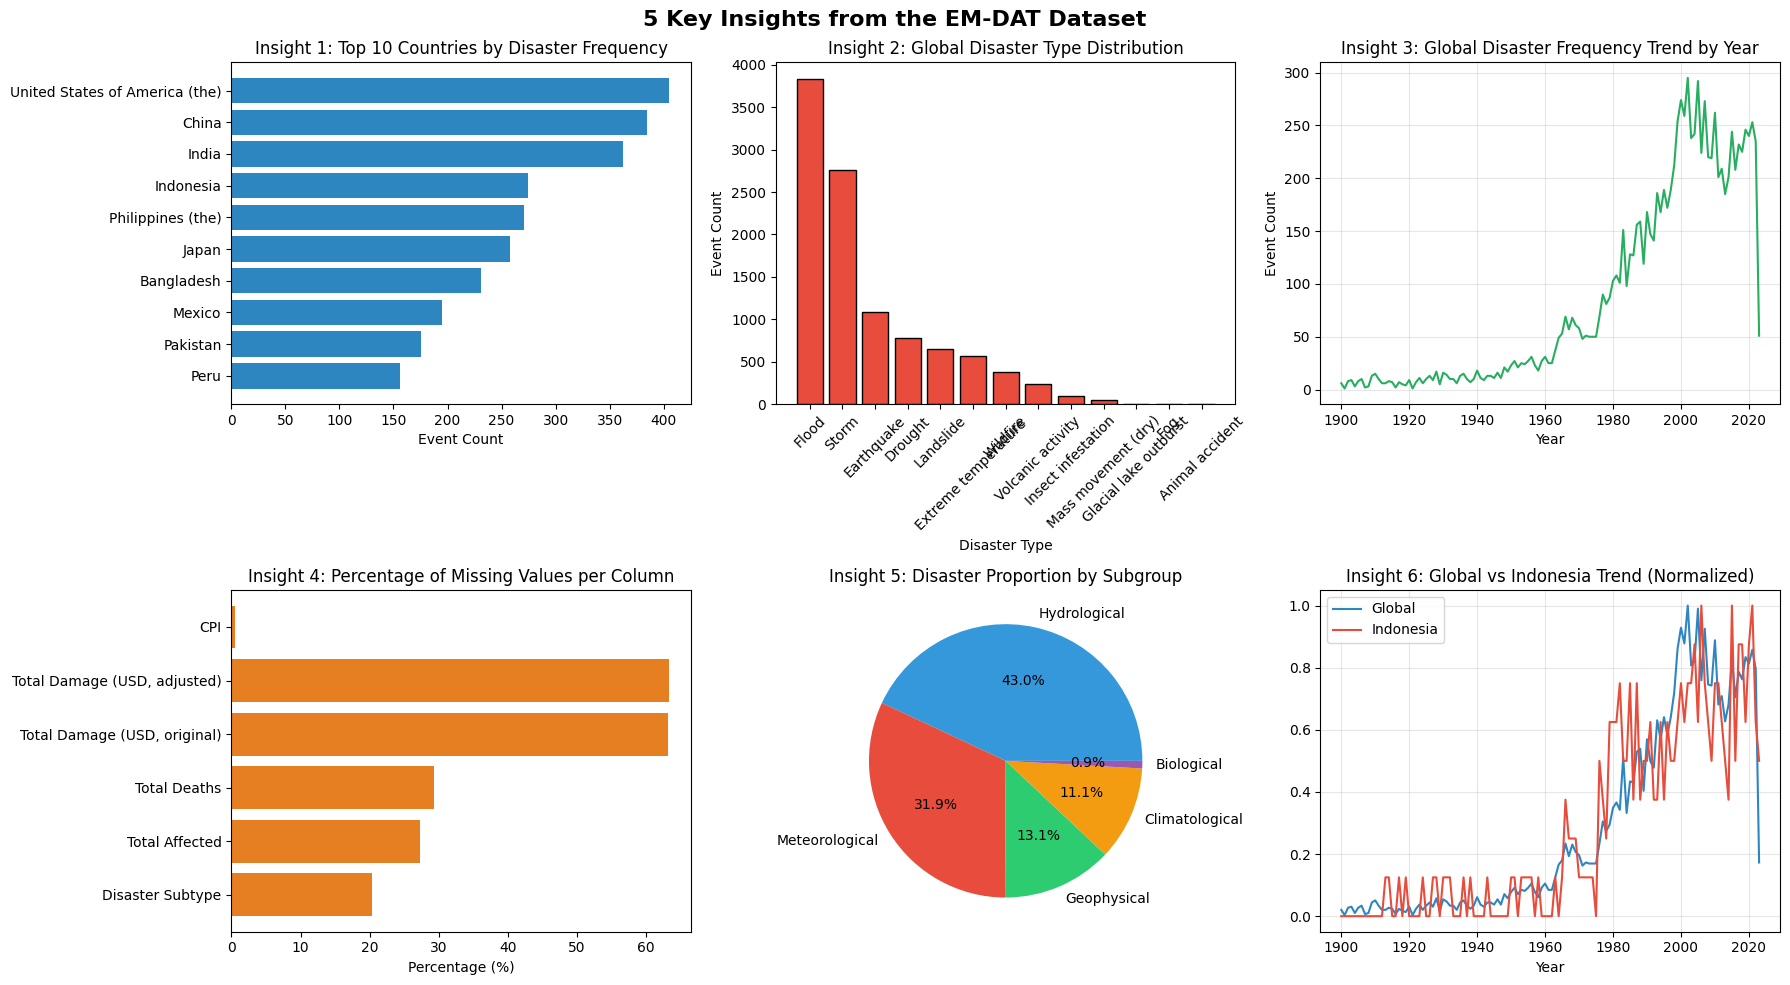

✅ 5 Key Insights complete!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('5 Key Insights from the EM-DAT Dataset', fontsize=16, fontweight='bold')

# Insight 1: Top 10 countries with most natural disaster events
top_countries = df['Country'].value_counts().head(10)
axes[0,0].barh(top_countries.index[::-1], top_countries.values[::-1], color='#2E86C1')
axes[0,0].set_title('Insight 1: Top 10 Countries by Disaster Frequency')
axes[0,0].set_xlabel('Event Count')

# Insight 2: Distribution of disaster types
disaster_counts = df['Disaster Type'].value_counts()
axes[0,1].bar(disaster_counts.index, disaster_counts.values, color='#E74C3C', edgecolor='black')
axes[0,1].set_title('Insight 2: Global Disaster Type Distribution')
axes[0,1].set_xlabel('Disaster Type')
axes[0,1].set_ylabel('Event Count')
axes[0,1].tick_params(axis='x', rotation=45)

# Insight 3: Global disaster trend by year
trend_global = df.groupby('Year').size().reset_index(name='Count')
axes[0,2].plot(trend_global['Year'], trend_global['Count'], color='#27AE60', linewidth=1.5)
axes[0,2].set_title('Insight 3: Global Disaster Frequency Trend by Year')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Event Count')
axes[0,2].grid(alpha=0.3)

# Insight 4: Missing values check
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing']
missing['Percentage'] = (missing['Missing'] / len(df) * 100).round(1)
missing_filtered = missing[missing['Missing'] > 0]
axes[1,0].barh(missing_filtered['Column'], missing_filtered['Percentage'], color='#E67E22')
axes[1,0].set_title('Insight 4: Percentage of Missing Values per Column')
axes[1,0].set_xlabel('Percentage (%)')

# Insight 5: Disaster proportion per subgroup
subgroup_counts = df['Disaster Subroup'].value_counts()
axes[1,1].pie(subgroup_counts.values, labels=subgroup_counts.index,
              autopct='%1.1f%%', colors=['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6'])
axes[1,1].set_title('Insight 5: Disaster Proportion by Subgroup')

# Insight 6: Global vs Indonesia Trend
trend_indo = df[df['Country'] == 'Indonesia'].groupby('Year').size().reset_index(name='Indonesia')
trend_merged = trend_global.merge(trend_indo, on='Year', how='left').fillna(0)
trend_merged['Global_norm'] = trend_merged['Count'] / trend_merged['Count'].max()
trend_merged['Indo_norm'] = trend_merged['Indonesia'] / trend_merged['Indonesia'].max()
axes[1,2].plot(trend_merged['Year'], trend_merged['Global_norm'], label='Global', color='#2E86C1', linewidth=1.5)
axes[1,2].plot(trend_merged['Year'], trend_merged['Indo_norm'], label='Indonesia', color='#E74C3C', linewidth=1.5)
axes[1,2].set_title('Insight 6: Global vs Indonesia Trend (Normalized)')
axes[1,2].set_xlabel('Year')
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 5 Key Insights complete!")

> 📌 **Insight 1 — Top Countries**: The United States, China, India, Indonesia, and the Philippines account for the highest number of recorded disaster events, reflecting both geographic exposure and historical record-keeping quality.
>
> 📌 **Insight 2 — Dominant Disaster Types**: Flood (3,837 events) and Storm (2,761 events) together account for over 62% of all recorded disasters — both are hydrometeorological events strongly linked to climate variability.
>
> 📌 **Insight 3 — Global Trend**: The number of recorded disasters per year increases dramatically from the 1950s onward, consistent with scientific consensus on climate-driven disaster acceleration.
>
> 📌 **Insight 4 — Missing Data Pattern**: Damage-related columns have the highest proportion of missing values (>60%), suggesting economic impact data was not systematically collected in earlier decades.
>
> 📌 **Insight 5 — Subgroup Distribution**: Hydrological (43%) and Meteorological (31.9%) disasters dominate, comprising 75% of all events.
>
> 📌 **Insight 6 — Indonesia vs. Global**: Indonesia's disaster frequency follows the global upward trend but with steeper growth since the 1990s.

### 2.2 Data Quality Check — Outliers & Correlation
We examine numeric columns for extreme values using boxplots, and check for linear relationships between features using a correlation heatmap.

**Why this matters**: Outliers in impact columns (`Total Deaths, Total Affected`) are expected—major disasters like the 2004 Indian Ocean Tsunami represent legitimate extreme events, not data errors. Furthermore, the low correlation observed between Total Events and other impact metrics is statistically significant; it indicates that event frequency does not have a strong linear relationship with severity. This is expected, as high-frequency, low-impact events (such as localized flooding) do not necessarily correlate with the catastrophic death tolls seen in rare, high-impact events.

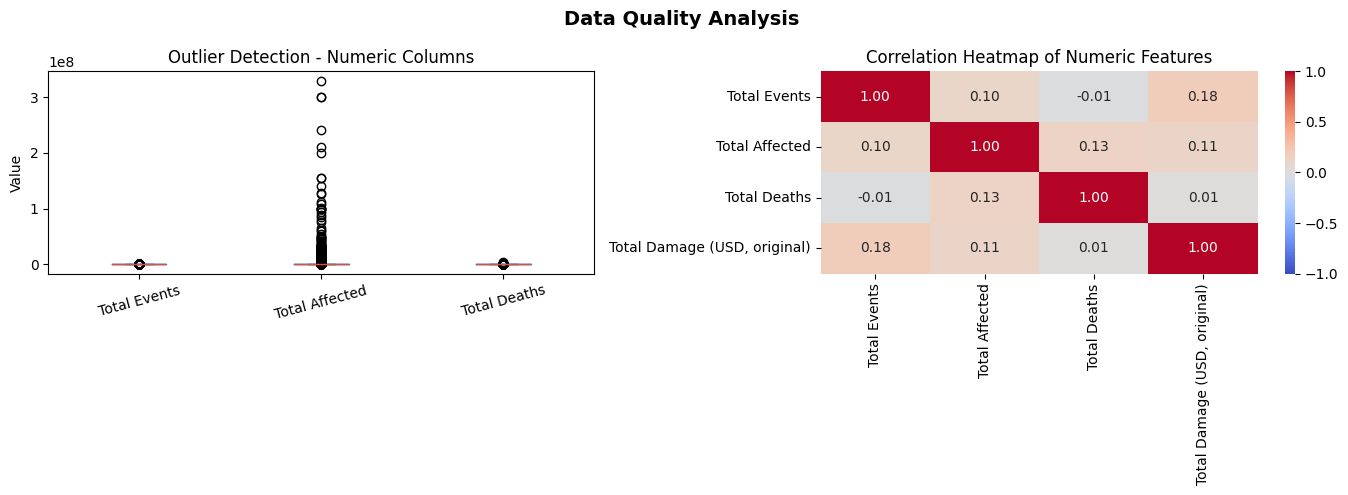

=== OUTLIER STATISTICS ===
Total Events: 2356 outlier (22.6%)
Total Affected: 1291 outlier (12.4%)
Total Deaths: 1040 outlier (10.0%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Quality Analysis', fontsize=14, fontweight='bold')

# Outlier boxplot visualization
numeric_cols = ['Total Events', 'Total Affected', 'Total Deaths']
df[numeric_cols].plot(kind='box', ax=axes[0],
                       color=dict(boxes='#2E86C1', whiskers='#2E86C1',
                                  medians='#E74C3C', caps='#2E86C1'))
axes[0].set_title('Outlier Detection - Numeric Columns')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=15)

# Correlation heatmap
df_corr = df.copy()
df_corr['CPI'] = df_corr['CPI'].astype(str).str.replace(',', '.').astype(float)
corr_cols = ['Total Events', 'Total Affected', 'Total Deaths', 'Total Damage (USD, original)']
corr_matrix = df_corr[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Correlation Heatmap of Numeric Features')

plt.tight_layout()
plt.savefig('outlier_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Outlier statistics calculation
print("=== OUTLIER STATISTICS ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    print(f"{col}: {outliers} outlier ({outliers/len(df)*100:.1f}%)")

> 📌 **Outliers**: Extreme outliers exist in `Total Deaths` and `Total Affected`, consistent with catastrophic events (e.g. 1970 Bhola Cyclone, 2004 Indian Ocean Tsunami). These are **retained** as they represent real events relevant to the model.
>
> 📌 **Correlation**: `Total Affected` and `Total Deaths` show low-to-moderate correlation. `Total Events` shows weak correlation with impact metrics, indicating that frequency alone does not predict severity.

## 🛠️ Step 3: Data Preparation

### 3.1 Case Study — Flood Frequency Trend in Indonesia
Before building global models, we drill into Indonesia × Flood as a case study to validate our aggregation approach and confirm the trend hypothesis at a granular level.

**Why Indonesia × Flood?** Indonesia ranks 4th globally in total disaster events, and Flood is the most frequent disaster type worldwide — providing a rich, well-populated time series for trend validation.

In [6]:
# Filter data for Indonesia & Flood
df_indo_flood = df[(df['Country'] == 'Indonesia') & (df['Disaster Type'] == 'Flood')].copy()
print(f"Total flood events in Indonesia: {len(df_indo_flood)}")
print(f"Year range: {df_indo_flood['Year'].min()} - {df_indo_flood['Year'].max()}")
print(f"\nMissing values:")
print(df_indo_flood.isnull().sum())
df_indo_flood.head(10)

Total flood events in Indonesia: 89
Year range: 1953 - 2023

Missing values:
Year                             0
Country                          0
ISO                              0
Disaster Group                   0
Disaster Subroup                 0
Disaster Type                    0
Disaster Subtype                34
Total Events                     0
Total Affected                   5
Total Deaths                     4
Total Damage (USD, original)    49
Total Damage (USD, adjusted)    49
CPI                              1
dtype: int64


,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
550,1953,Indonesia,IDN,Natural,Hydrological,Flood,NaN,1,NaN,114.0,NaN,NaN,"9,1626554588977"
966,1966,Indonesia,IDN,Natural,Hydrological,Flood,Riverine flood,1,524100.0,176.0,33000000.0,297538621.0,"11,0909971475822"
1027,1967,Indonesia,IDN,Natural,Hydrological,Flood,NaN,4,204000.0,160.0,NaN,NaN,"11,3985269797253"
1090,1968,Indonesia,IDN,Natural,Hydrological,Flood,NaN,1,150000.0,12.0,7831000.0,65887302.0,"11,8854465143325"
1219,1970,Indonesia,IDN,Natural,Hydrological,Flood,NaN,1,NaN,82.0,NaN,NaN,"13,2664799609959"
1535,1976,Indonesia,IDN,Natural,Hydrological,Flood,Flash flood,1,20020.0,163.0,NaN,NaN,"19,4455440893725"
1603,1977,Indonesia,IDN,Natural,Hydrological,Flood,NaN,3,290000.0,22.0,NaN,NaN,"20,7098324994209"
1689,1978,Indonesia,IDN,Natural,Hydrological,Flood,NaN,4,281600.0,70.0,NaN,NaN,"22,2901950366959"
1775,1979,Indonesia,IDN,Natural,Hydrological,Flood,NaN,3,34850.0,164.0,3200000.0,12903829.0,"24,7988405675032"
1868,1980,Indonesia,IDN,Natural,Hydrological,Flood,NaN,1,2946.0,153.0,3400000.0,12074341.0,"28,1588866338069"


> ✅ **Result**: **89 flood events** recorded in Indonesia between **1953 and 2023** — sufficient for meaningful decade-level trend analysis.
>
> Missing values in impact columns do not affect this analysis since we model **frequency** (event counts), not impact severity.

### 3.2 Decade-Level Aggregation & Normalization
We group events by decade to smooth year-to-year noise and reveal the long-term trend.

**Normalization**: The 2020s decade is incomplete (data through 2023 = 4 years only). A raw count comparison would unfairly underrepresent it, so we divide total events by the number of years recorded in each decade to get **average events per year** — making all decades directly comparable.

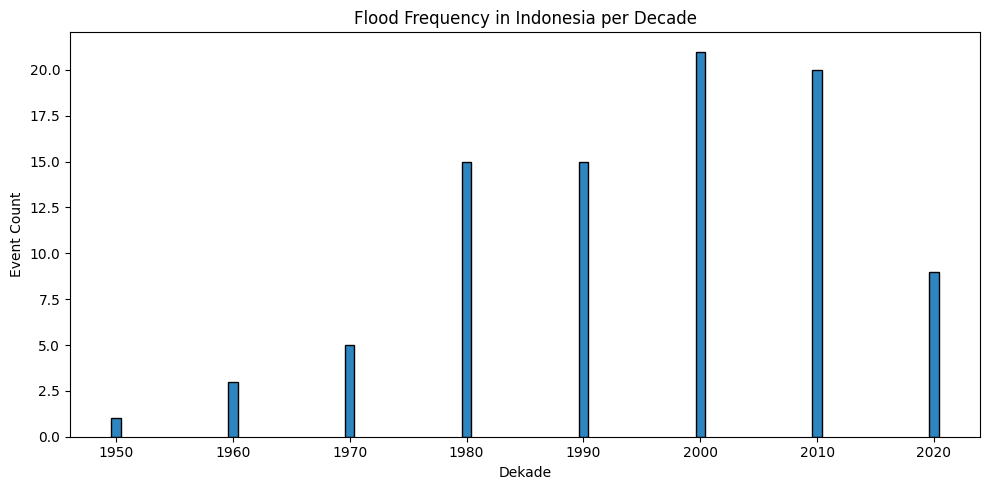

   Decade  Disaster_Count
0    1950               1
1    1960               3
2    1970               5
3    1980              15
4    1990              15
5    2000              21
6    2010              20
7    2020               9


In [7]:
# Aggregate data by decade
df_indo_flood['Decade'] = (df_indo_flood['Year'] // 10) * 10
freq_per_decade = df_indo_flood.groupby('Decade').size().reset_index(name='Disaster_Count')

# Generate bar chart by decade
plt.figure(figsize=(10,5))
plt.bar(freq_per_decade['Decade'], freq_per_decade['Disaster_Count'],
        color='#2E86C1', edgecolor='black')
plt.title('Flood Frequency in Indonesia per Decade')
plt.xlabel('Dekade')
plt.ylabel('Event Count')
plt.tight_layout()
plt.savefig('flood_per_decade.png', dpi=150)
plt.show()
print(freq_per_decade)

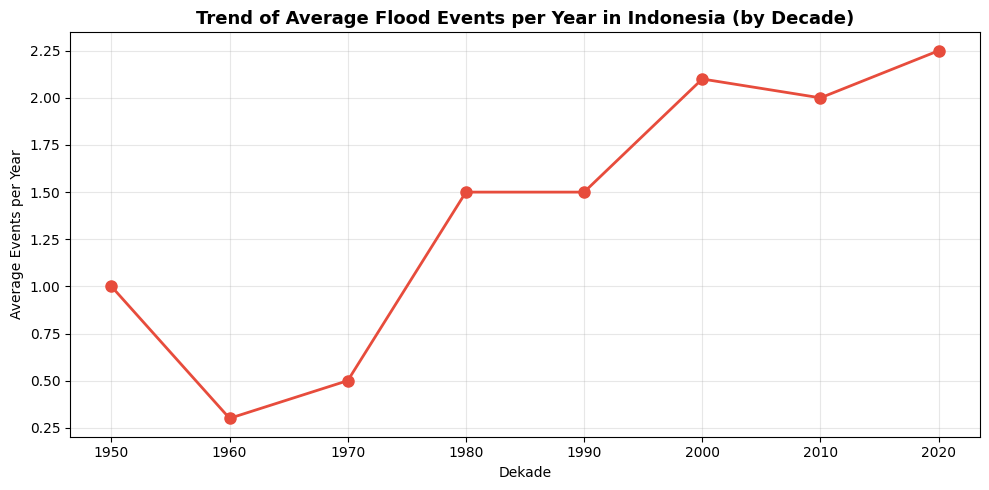

   Decade  Disaster_Count  Years_in_Decade  Annual_Average
0    1950               1                1            1.00
1    1960               3               10            0.30
2    1970               5               10            0.50
3    1980              15               10            1.50
4    1990              15               10            1.50
5    2000              21               10            2.10
6    2010              20               10            2.00
7    2020               9                4            2.25


In [8]:
# Normalization per year (2020s decade is incomplete in the dataset)
decade_years = {
    1950: 1, 1960: 10, 1970: 10, 1980: 10,
    1990: 10, 2000: 10, 2010: 10, 2020: 4
}
freq_per_decade['Years_in_Decade'] = freq_per_decade['Decade'].map(decade_years)
freq_per_decade['Annual_Average'] = (
    freq_per_decade['Disaster_Count'] / freq_per_decade['Years_in_Decade']
).round(2)

# Generate line chart trend
plt.figure(figsize=(10,5))
plt.plot(freq_per_decade['Decade'], freq_per_decade['Annual_Average'],
         marker='o', linewidth=2, color='#E74C3C', markersize=8)
plt.title('Trend of Average Flood Events per Year in Indonesia (by Decade)',
          fontsize=13, fontweight='bold')
plt.xlabel('Dekade')
plt.ylabel('Average Events per Year')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('indonesia_flood_trend.png', dpi=150)
plt.show()
print(freq_per_decade)

> 📌 **Key Finding**: After normalization, the 2020s (2.25 events/year) already exceed all previous decades despite only 4 years of data. The trend from the 1960s (0.30/year) to the 2020s (2.25/year) represents a **~7.5× increase** in annual flood frequency — strongly supporting the hypothesis that disaster frequency is increasing.

### 3.3 Save Processed Data
We save the aggregated datasets to CSV so that Notebooks 2 and 3 can load them directly without re-running the full preprocessing pipeline.

In [9]:
# Save processed data to be used in notebook 2
agg = df.groupby(['Country', 'Disaster Type', 'Year']).size().reset_index(name='Disaster_Count')
agg.to_csv('processed_agg.csv', index=False)
freq_per_decade.to_csv('processed_indo_flood.csv', index=False)
print(f"✅ Data processed tersimpan!")
print(f"   - processed_agg.csv       : {len(agg)} rows")
print(f"   - processed_indo_flood.csv: {len(freq_per_decade)} rows")

✅ Data processed tersimpan!
   - processed_agg.csv       : 9200 rows
   - processed_indo_flood.csv: 8 rows
